✅ Dataset Loaded Successfully!
Shape: (9841, 57)

--- Data Types ---
float64    48
object      9
Name: count, dtype: int64

--- Sample Records ---


,Timestamp,IP_Address,Protocol,Flag_Code,Threat_Type,Prediction,Family,Action_Taken,Status,FLAG,...,ERC20 min val sent,ERC20 max val sent,ERC20 avg val sent,ERC20 min val sent contract,ERC20 max val sent contract,ERC20 avg val sent contract,ERC20 uniq sent token name,ERC20 uniq rec token name,ERC20 most sent token type,ERC20_most_rec_token_type
0,2025-11-08 16:04:08.403954,192.168.189.46,UDP,AP,UDP Scan,S,Razy,No Action,Success,0.0,...,0.000000e+00,1.502768e-04,4.840458e-06,0.0,0.0,0.0,0.183099,0.077341,0.206557,0.642398
1,2025-11-08 16:04:13.403954,192.168.154.169,ICMP,R,DoS,S,Razy,No Action,Pending,0.0,...,2.260809e-08,2.018579e-11,4.026549e-11,0.0,0.0,0.0,0.004695,0.009498,0.504918,0.550321
2,2025-11-08 16:04:18.403954,192.168.134.89,UDP,R,Port Scanning,S,Razy,Blocked IP,Pending,0.0,...,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.000000,0.010855,0.606557,0.933619
3,2025-11-08 16:04:23.403954,192.168.35.135,UDP,AP,UDP Scan,S,CryptoLocker,Rate Limited,Pending,0.0,...,1.000000e-06,8.061813e-08,6.775142e-08,0.0,0.0,0.0,0.004695,0.014925,0.711475,0.933619
4,2025-11-08 16:04:28.403954,192.168.85.59,UDP,A,Spam,SS,WannaCry,Blocked IP,Success,0.0,...,0.000000e+00,4.017857e-07,2.444747e-07,0.0,0.0,0.0,0.028169,0.036635,0.780328,0.329764


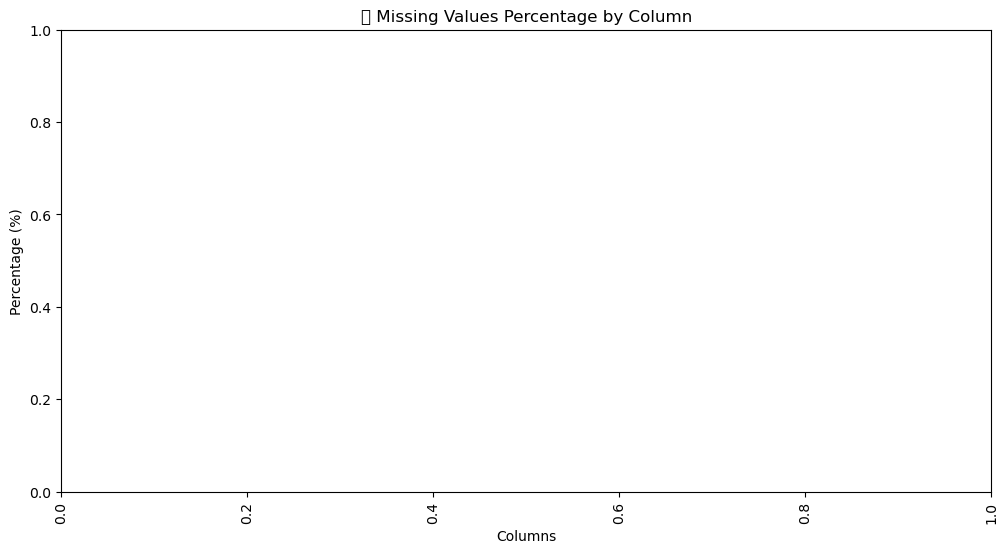

✅ No missing values detected.

🔁 Number of duplicate rows: 0

--- Descriptive Statistics (Numeric Columns) ---


,count,mean,std,min,25%,50%,75%,max
FLAG,9841.0,0.221421,0.415224,0.0,0.000000e+00,0.000000e+00,0.000000e+00,1.0
Avg min between sent tnx,9841.0,0.011822,0.049935,0.0,0.000000e+00,4.029862e-05,1.314167e-03,1.0
Avg min between received tnx,9841.0,0.016602,0.047870,0.0,0.000000e+00,1.057229e-03,1.136597e-02,1.0
Time Diff between first and last (Mins),9841.0,0.111687,0.165197,0.0,1.621241e-04,2.385696e-02,1.555461e-01,1.0
Sent tnx,9841.0,0.011593,0.075723,0.0,1.000000e-04,3.000000e-04,1.100000e-03,1.0
Received Tnx,9841.0,0.016370,0.094084,0.0,1.000000e-04,4.000000e-04,2.700000e-03,1.0
Number of Created Contracts,9841.0,0.000373,0.014152,0.0,0.000000e+00,0.000000e+00,0.000000e+00,1.0
Unique Received From Addresses,9841.0,0.003036,0.029865,0.0,1.000100e-04,2.000200e-04,5.000500e-04,1.0
Unique Sent To Addresses,9841.0,0.002782,0.028407,0.0,1.076774e-04,2.153548e-04,3.230322e-04,1.0
min value received,9841.0,0.004385,0.032593,0.0,1.000000e-07,9.585600e-06,2.000000e-04,1.0


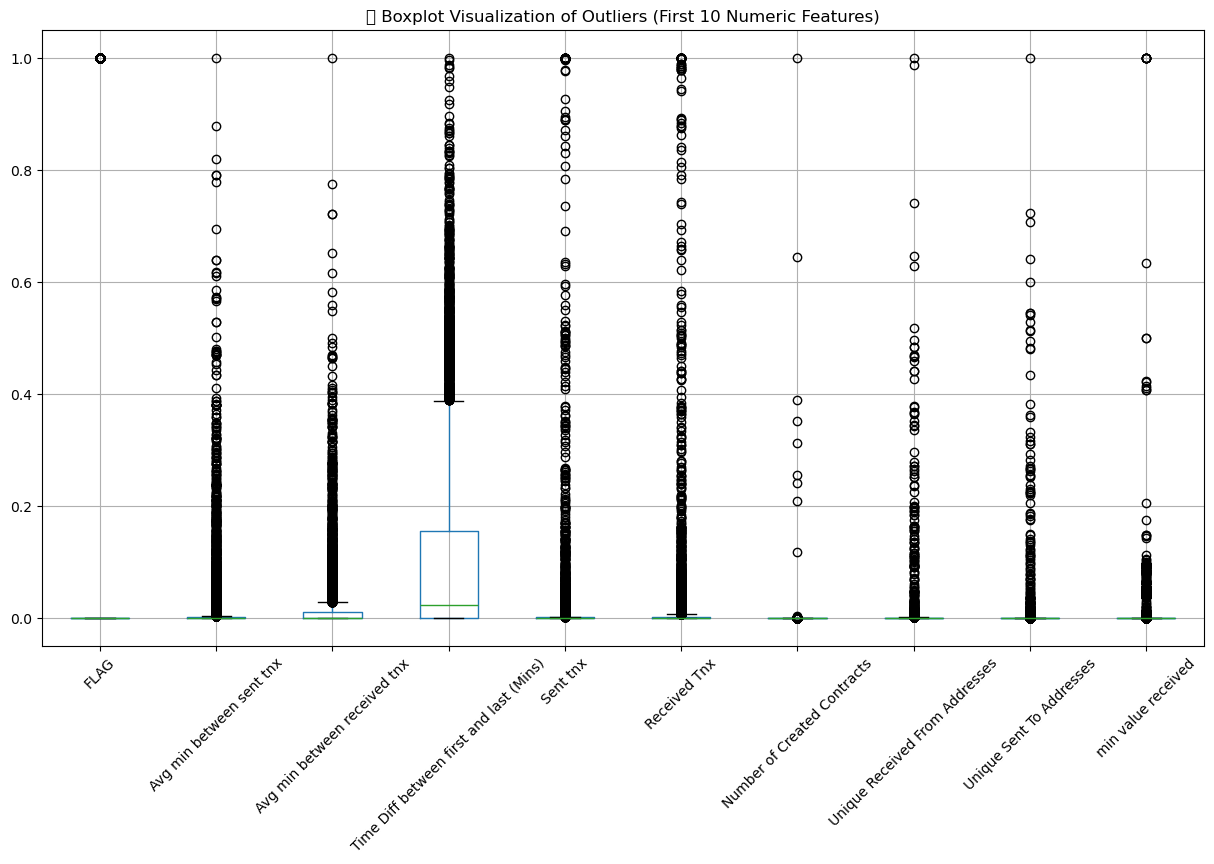

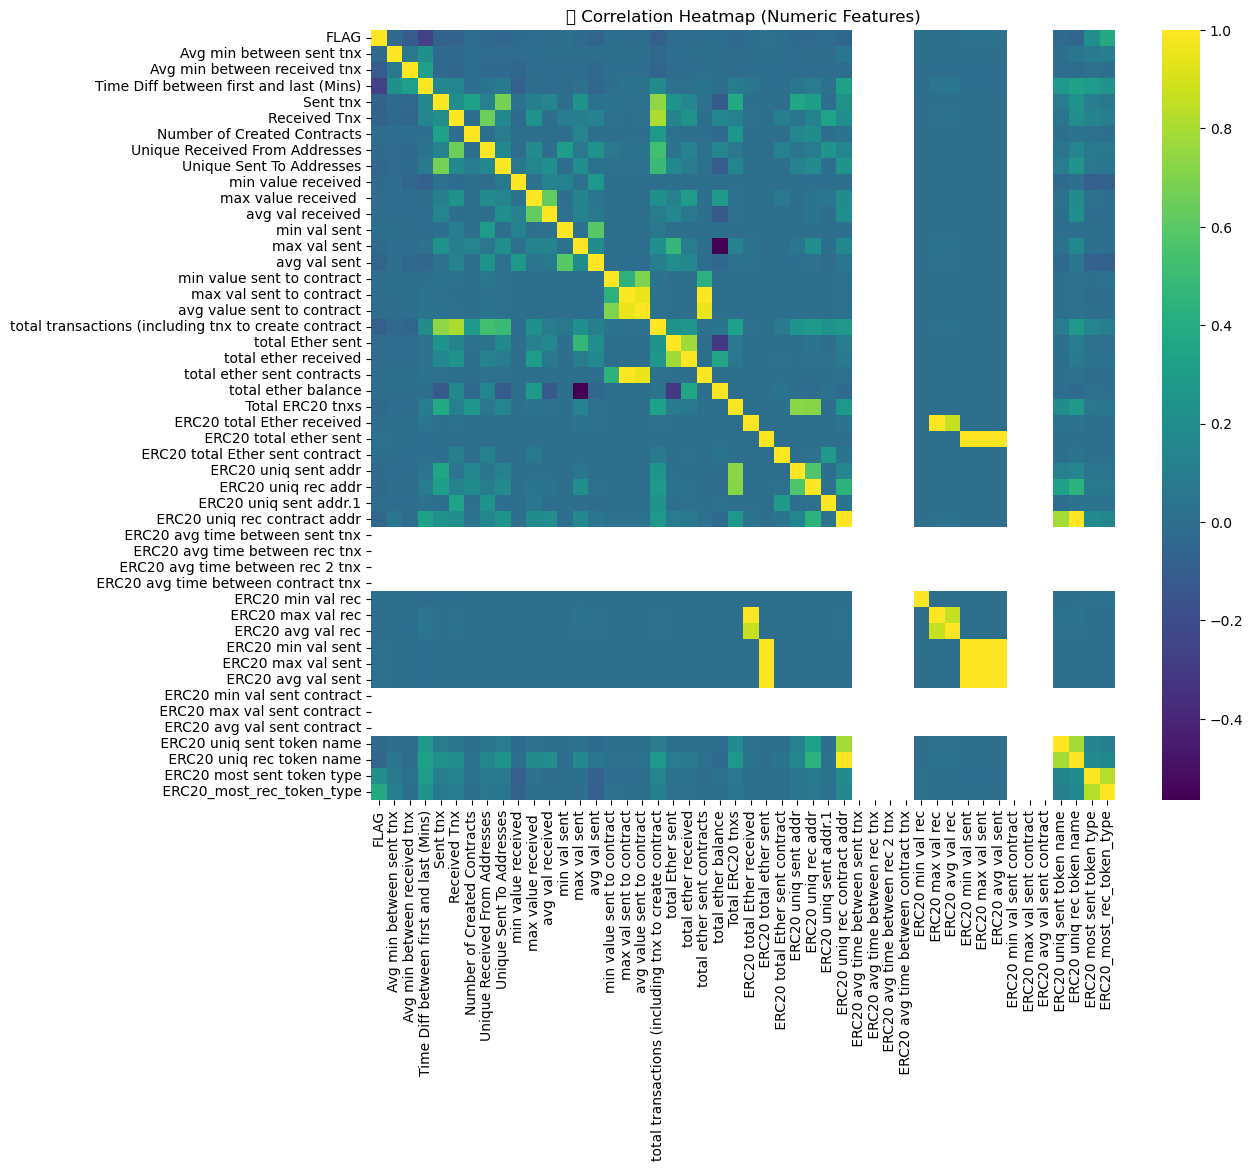

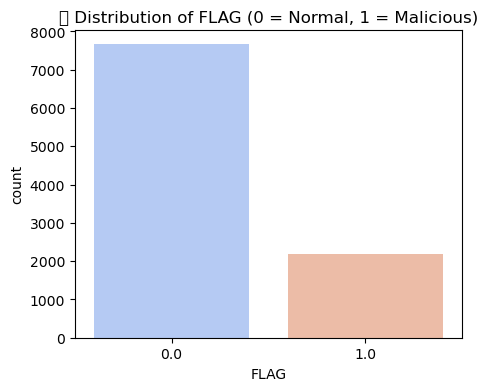

In [1]:
# ================================================================
# Smart Intrusion Detection Model (SIDM)
# Data Quality and Visualization - Step 1
# ================================================================

# Import essential libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# --------------------------------------------
# Load the dataset
# --------------------------------------------
file_path = r"C:\Users\HP\Desktop\model\adaji.csv"
df = pd.read_csv(file_path)

# Display basic info
print("✅ Dataset Loaded Successfully!")
print(f"Shape: {df.shape}")
print("\n--- Data Types ---")
print(df.dtypes.value_counts())
print("\n--- Sample Records ---")
display(df.head())

# --------------------------------------------
# Missing Values Visualization
# --------------------------------------------
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Values': missing, 'Percent (%)': missing_percent})
missing_df = missing_df[missing_df['Missing Values'] > 0].sort_values(by='Percent (%)', ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x=missing_df.index, y='Percent (%)', data=missing_df, palette="coolwarm")
plt.xticks(rotation=90)
plt.title("📊 Missing Values Percentage by Column")
plt.xlabel("Columns")
plt.ylabel("Percentage (%)")
plt.show()

if missing_df.empty:
    print("✅ No missing values detected.")

# --------------------------------------------
# Duplicate Records
# --------------------------------------------
duplicates = df.duplicated().sum()
print(f"\n🔁 Number of duplicate rows: {duplicates}")
if duplicates > 0:
    print("⚠️ Consider removing duplicates using df.drop_duplicates().")

# --------------------------------------------
# Statistical Overview (for numeric features)
# --------------------------------------------
print("\n--- Descriptive Statistics (Numeric Columns) ---")
display(df.describe().T)

# --------------------------------------------
# Outlier Detection using Boxplots
# --------------------------------------------
numeric_cols = df.select_dtypes(include=[np.number]).columns
sample_cols = numeric_cols[:10]  # visualize first 10 numeric columns

plt.figure(figsize=(15,8))
df[sample_cols].boxplot()
plt.title("📦 Boxplot Visualization of Outliers (First 10 Numeric Features)")
plt.xticks(rotation=45)
plt.show()

# --------------------------------------------
# Correlation Heatmap (for feature relationships)
# --------------------------------------------
plt.figure(figsize=(12,10))
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, cmap='viridis', annot=False)
plt.title("🔥 Correlation Heatmap (Numeric Features)")
plt.show()

# --------------------------------------------
# Distribution of Target Variable (FLAG)
# --------------------------------------------
if 'FLAG' in df.columns:
    plt.figure(figsize=(5,4))
    sns.countplot(x='FLAG', data=df, palette='coolwarm')
    plt.title("🎯 Distribution of FLAG (0 = Normal, 1 = Malicious)")
    plt.show()
else:
    print("⚠️ FLAG column not found. Ensure target variable exists.")


In [2]:
!pip install -U imbalanced-learn


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


✅ Dataset Loaded Successfully!
Initial shape: (9841, 57)

🎯 FLAG class distribution before cleaning:
FLAG
0.0    7662
1.0    2179
Name: count, dtype: int64

📦 Outlier capping applied (no rows removed).
🔤 Encoding 9 categorical columns...
📏 Feature scaling completed using StandardScaler.

🎯 FLAG distribution before SMOTE:
FLAG
0.0    7662
1.0    2179
Name: count, dtype: int64

✅ SMOTE Balancing Complete!
--- Class Distribution After SMOTE ---
FLAG
0.0    7662
1.0    7662
Name: count, dtype: int64

💾 Cleaned dataset saved successfully to:
📂 C:\Users\HP\Desktop\model\adaji_cleaned.csv
🧮 Final shape: (15324, 57)


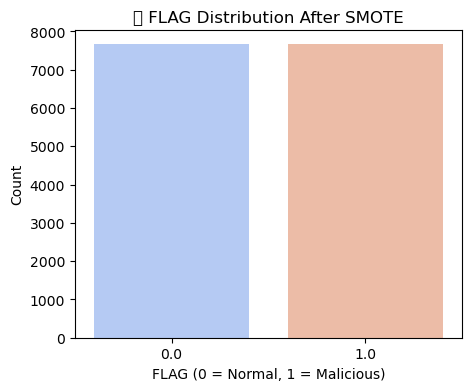


--- Sample of Final Cleaned Data ---


,Timestamp,IP_Address,Protocol,Flag_Code,Threat_Type,Prediction,Family,Action_Taken,Status,Avg min between sent tnx,...,ERC20 max val sent,ERC20 avg val sent,ERC20 min val sent contract,ERC20 max val sent contract,ERC20 avg val sent contract,ERC20 uniq sent token name,ERC20 uniq rec token name,ERC20 most sent token type,ERC20_most_rec_token_type,FLAG
0,0,3616,2,1,8,1,5,2,2,0.820134,...,0.0,0.0,0.0,0.0,0.0,0.0,1.945409,-0.237300,0.918016,0.0
1,1,2224,0,2,2,1,5,2,1,1.805554,...,0.0,0.0,0.0,0.0,0.0,0.0,1.945409,0.596308,0.661955,0.0
2,2,1479,2,2,4,1,5,0,1,1.805554,...,0.0,0.0,0.0,0.0,0.0,0.0,1.945409,0.880285,1.727884,0.0
3,3,6615,2,1,8,1,1,3,1,1.805554,...,0.0,0.0,0.0,0.0,0.0,0.0,1.945409,1.173422,1.727884,0.0
4,4,8597,2,0,7,2,8,0,2,-0.577571,...,0.0,0.0,0.0,0.0,0.0,0.0,1.945409,1.365793,0.048599,0.0


In [62]:
# ================================================================
# SMART INTRUSION DETECTION MODEL (SIDM)
# Data Cleaning, Preprocessing & Feature Engineering (Fixed)
# ================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE
import warnings, os
warnings.filterwarnings("ignore")

# --------------------------------------------
# 1. Load Dataset
# --------------------------------------------
file_path = r"C:\Users\HP\Desktop\model\adaji.csv"
df = pd.read_csv(file_path)

print("✅ Dataset Loaded Successfully!")
print(f"Initial shape: {df.shape}")

# --------------------------------------------
# 2. Basic Cleaning
# --------------------------------------------
df = df.drop_duplicates()
df = df.fillna(df.median(numeric_only=True))

# Ensure FLAG exists and has at least 2 classes
if 'FLAG' not in df.columns:
    raise ValueError("❌ 'FLAG' column not found in dataset!")

print("\n🎯 FLAG class distribution before cleaning:")
print(df['FLAG'].value_counts())

# --------------------------------------------
# 3. Handle Outliers (Feature-wise Capping)
# --------------------------------------------
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop('FLAG', errors='ignore')

for col in numeric_cols:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    df[col] = np.clip(df[col], lower, upper)

print("\n📦 Outlier capping applied (no rows removed).")

# --------------------------------------------
# 4. Encode Categorical Columns (excluding FLAG)
# --------------------------------------------
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
cat_cols = [c for c in cat_cols if c != 'FLAG']  # safety check

if cat_cols:
    print(f"🔤 Encoding {len(cat_cols)} categorical columns...")
    le = LabelEncoder()
    for c in cat_cols:
        df[c] = le.fit_transform(df[c].astype(str))
else:
    print("✅ No categorical columns found for encoding.")

# --------------------------------------------
# 5. Feature Scaling
# --------------------------------------------
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
print("📏 Feature scaling completed using StandardScaler.")

# --------------------------------------------
# 6. Verify FLAG Class Balance Before SMOTE
# --------------------------------------------
print("\n🎯 FLAG distribution before SMOTE:")
print(df['FLAG'].value_counts())

if df['FLAG'].nunique() < 2:
    raise ValueError("❌ FLAG column contains only one class. Please verify your dataset before resampling.")

# --------------------------------------------
# 7. Apply SMOTE for Balancing
# --------------------------------------------
X = df.drop(columns=['FLAG'])
y = df['FLAG']

sm = SMOTE(random_state=42)
X_bal, y_bal = sm.fit_resample(X, y)

print("\n✅ SMOTE Balancing Complete!")
print("--- Class Distribution After SMOTE ---")
print(y_bal.value_counts())

# --------------------------------------------
# 8. Save Final Cleaned Dataset
# --------------------------------------------
df_cleaned = X_bal.copy()
df_cleaned['FLAG'] = y_bal

save_path = r"C:\Users\HP\Desktop\model\adaji_cleaned.csv"
df_cleaned.to_csv(save_path, index=False)

print(f"\n💾 Cleaned dataset saved successfully to:\n📂 {save_path}")
print(f"🧮 Final shape: {df_cleaned.shape}")

# --------------------------------------------
# 9. Summary Visualization
# --------------------------------------------
plt.figure(figsize=(5,4))
sns.countplot(x='FLAG', data=df_cleaned, palette='coolwarm')
plt.title("🎯 FLAG Distribution After SMOTE")
plt.xlabel("FLAG (0 = Normal, 1 = Malicious)")
plt.ylabel("Count")
plt.show()

print("\n--- Sample of Final Cleaned Data ---")
display(df_cleaned.head())


In [69]:
!pip install xgboost

   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.8/72.0 MB 1.8 MB/s eta 0:00:41
    --------------------------------------- 1.3/72.0 MB 1.7 MB/s eta 0:00:43
   - -------------------------------------- 1.8/72.0 MB 1.9 MB/s eta 0:00:37
   - -------------------------------------- 2.4/72.0 MB 2.1 MB/s eta 0:00:33
   - -------------------------------------- 2.9/72.0 MB 2.2 MB/s eta 0:00:32
   - -------------------------------------- 3.4/72.0 MB 2.2 MB/s eta 0:00:32
   -- ------------------------------------- 3.9/72.0 MB 2.3 MB/s eta 0:00:30
   -- ------------------------------------- 4.7/72.0 MB 2.4 MB/s eta 0:00:28
   -- ----------------------------


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [71]:
# ================================================================
# SMART INTRUSION DETECTION MODEL (SIDM)
# Hybrid Machine Learning System: RF + XGBoost + LSTM
# ================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical

# --------------------------------------------
# Load Cleaned Dataset
# --------------------------------------------
data_path = r"C:\Users\HP\Desktop\model\adaji_cleaned_restored.csv"
df = pd.read_csv(data_path)

print("✅ Cleaned dataset loaded successfully!")
print("Shape:", df.shape)
print(df['FLAG'].value_counts())


✅ Cleaned dataset loaded successfully!
Shape: (15324, 57)
FLAG
0.0    7662
1.0    7662
Name: count, dtype: int64


In [73]:
# Drop identifiers
X = df.drop(columns=['FLAG', 'Timestamp', 'IP_Address'], errors='ignore')
y = df['FLAG']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)


Training set: (11493, 54)
Testing set: (3831, 54)


In [75]:
# --------------------------------------------
# Random Forest Classifier
# --------------------------------------------
rf = RandomForestClassifier(n_estimators=150, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("\n🌲 Random Forest Performance:")
print(classification_report(y_test, rf_pred))
rf_acc = accuracy_score(y_test, rf_pred)
print("Accuracy:", rf_acc)

# --------------------------------------------
# XGBoost Classifier
# --------------------------------------------
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

print("\n⚡ XGBoost Performance:")
print(classification_report(y_test, xgb_pred))
xgb_acc = accuracy_score(y_test, xgb_pred)
print("Accuracy:", xgb_acc)



🌲 Random Forest Performance:
              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99      1916
         1.0       0.99      0.99      0.99      1915

    accuracy                           0.99      3831
   macro avg       0.99      0.99      0.99      3831
weighted avg       0.99      0.99      0.99      3831

Accuracy: 0.9924301748890629

⚡ XGBoost Performance:
              precision    recall  f1-score   support

         0.0       0.99      1.00      1.00      1916
         1.0       1.00      0.99      1.00      1915

    accuracy                           1.00      3831
   macro avg       1.00      1.00      1.00      3831
weighted avg       1.00      1.00      1.00      3831

Accuracy: 0.995301487862177


In [77]:
# --------------------------------------------
# Prepare Data for LSTM
# --------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = X_scaled.reshape(X_scaled.shape[0], X_scaled.shape[1], 1)

y_cat = to_categorical(y)

X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm = train_test_split(
    X_scaled, y_cat, test_size=0.25, random_state=42, stratify=y
)

# --------------------------------------------
# Build LSTM Model
# --------------------------------------------
lstm_model = Sequential([
    LSTM(64, input_shape=(X_train_lstm.shape[1], 1), return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(2, activation='softmax')
])

lstm_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = lstm_model.fit(
    X_train_lstm, y_train_lstm,
    epochs=10,
    batch_size=64,
    validation_data=(X_test_lstm, y_test_lstm),
    verbose=1
)

# Evaluate
loss, acc = lstm_model.evaluate(X_test_lstm, y_test_lstm)
print(f"\n🧠 LSTM Model Accuracy: {acc:.4f}")


Epoch 1/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 16s 59ms/step - accuracy: 0.8059 - loss: 0.4392 - val_accuracy: 0.8943 - val_loss: 0.2894
Epoch 2/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 10s 54ms/step - accuracy: 0.9159 - loss: 0.2194 - val_accuracy: 0.9316 - val_loss: 0.1856
Epoch 3/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 10s 53ms/step - accuracy: 0.9373 - loss: 0.1741 - val_accuracy: 0.9431 - val_loss: 0.1612
Epoch 4/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 10s 55ms/step - accuracy: 0.9401 - loss: 0.1649 - val_accuracy: 0.9407 - val_loss: 0.1630
Epoch 5/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 10s 55ms/step - accuracy: 0.9432 - loss: 0.1582 - val_accuracy: 0.9405 - val_loss: 0.1575
Epoch 6/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 10s 54ms/step - accuracy: 0.9441 - loss: 0.1543 - val_accuracy: 0.9488 - val_loss: 0.1455
Epoch 7/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 10s 56ms/step - accuracy: 0.9443 - loss: 0.1488 - val_accuracy: 0.9483 - val_loss: 0.1463
Epoch 8/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 11s 58ms/step - accuracy: 0.9485 - loss: 0.1411 - 

In [79]:
# --------------------------------------------
# Ensemble Prediction (Hybrid)
# --------------------------------------------
rf_probs = rf.predict_proba(X_test)
xgb_probs = xgb.predict_proba(X_test)
lstm_probs = lstm_model.predict(X_test_lstm)

# Align LSTM test size (if required)
min_len = min(len(rf_probs), len(lstm_probs))
ensemble_probs = (rf_probs[:min_len] + xgb_probs[:min_len] + lstm_probs[:min_len]) / 3
ensemble_pred = np.argmax(ensemble_probs, axis=1)

print("\n🤖 HYBRID MODEL (RF + XGB + LSTM) PERFORMANCE:")
print(classification_report(y_test[:min_len], ensemble_pred))
print("Hybrid Accuracy:", accuracy_score(y_test[:min_len], ensemble_pred))


120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step

🤖 HYBRID MODEL (RF + XGB + LSTM) PERFORMANCE:
              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99      1916
         1.0       1.00      0.99      0.99      1915

    accuracy                           0.99      3831
   macro avg       0.99      0.99      0.99      3831
weighted avg       0.99      0.99      0.99      3831

Hybrid Accuracy: 0.9929522317932654


In [81]:
import joblib

joblib.dump(rf, r"C:\Users\HP\Desktop\model\rf_model.pkl")
joblib.dump(xgb, r"C:\Users\HP\Desktop\model\xgb_model.pkl")
lstm_model.save(r"C:\Users\HP\Desktop\model\lstm_model.h5")

print("💾 Models saved successfully!")


💾 Models saved successfully!


In [96]:
# ================================================================
# SMART INTRUSION DETECTION MODEL (SIDM)
# Hybrid Ensemble Inference Engine (Auto-Align + Logging, Final Fix)
# ================================================================

import joblib
import numpy as np
import pandas as pd
from datetime import datetime
from tensorflow.keras.models import load_model
from sklearn.preprocessing import StandardScaler
import os

# --------------------------------------------
# 1. Load Saved Models
# --------------------------------------------
rf_model = joblib.load(r"C:\Users\HP\Desktop\model\rf_model.pkl")
xgb_model = joblib.load(r"C:\Users\HP\Desktop\model\xgb_model.pkl")
lstm_model = load_model(r"C:\Users\HP\Desktop\model\lstm_model.h5")

print("✅ Ensemble models loaded successfully!")

# --------------------------------------------
# 2. Load Scaler
# --------------------------------------------
scaler = StandardScaler()

# --------------------------------------------
# 3. Reference Columns from Training
# --------------------------------------------
feature_reference_path = r"C:\Users\HP\Desktop\model\adaji_cleaned_restored.csv"
feature_df = pd.read_csv(feature_reference_path)
feature_cols = (
    feature_df.drop(columns=['FLAG', 'Timestamp', 'IP_Address'], errors='ignore')
    .select_dtypes(include=[np.number])
    .columns.tolist()
)
expected_features = len(feature_cols)
print(f"📘 Loaded feature reference: {expected_features} features expected by model.")

# --------------------------------------------
# 4. Preprocessing Function
# --------------------------------------------
def preprocess_input(df):
    drop_cols = ['Timestamp', 'IP_Address', 'FLAG', 'Prediction', 'Threat_Label']
    df = df.drop(columns=[c for c in drop_cols if c in df.columns], errors='ignore')
    df = df.apply(pd.to_numeric, errors='coerce')
    for col in feature_cols:
        if col not in df.columns:
            df[col] = 0
    df = df[feature_cols]
    df = df.fillna(0)
    df_scaled = scaler.fit_transform(df)
    return df_scaled

# --------------------------------------------
# 5. Ensemble Prediction Function
# --------------------------------------------
def sidm_predict(input_df, log=True):
    """
    Performs hybrid ensemble prediction (RF + XGB + LSTM).
    Returns Timestamp, IP, Threat_Label, Confidence.
    Automatically logs results to CSV if log=True.
    """
    X_scaled = preprocess_input(input_df)
    X_lstm = X_scaled.reshape(X_scaled.shape[0], X_scaled.shape[1], 1)

    print(f"🧩 Model expects: {rf_model.n_features_in_} | Input features aligned: {X_scaled.shape[1]}")

    rf_p = rf_model.predict_proba(X_scaled)
    xgb_p = xgb_model.predict_proba(X_scaled)
    lstm_p = lstm_model.predict(X_lstm)

    avg_p = (rf_p + xgb_p + lstm_p) / 3
    predictions = np.argmax(avg_p, axis=1)
    confidence = np.max(avg_p, axis=1)

    result_df = input_df.copy()

    # Fallbacks for missing or NaN identifiers
    if 'Timestamp' not in result_df.columns or result_df['Timestamp'].isnull().any():
        result_df['Timestamp'] = pd.to_datetime(datetime.now())
    result_df['Timestamp'] = result_df['Timestamp'].fillna(pd.to_datetime(datetime.now()))

    if 'IP_Address' not in result_df.columns or result_df['IP_Address'].isnull().any():
        result_df['IP_Address'] = [
            f"192.168.{np.random.randint(0,255)}.{np.random.randint(1,255)}" for _ in range(len(result_df))
        ]
    else:
        # Replace NaN IPs only (pandas can't take list in fillna)
        result_df['IP_Address'] = result_df['IP_Address'].apply(
            lambda x: x if pd.notnull(x) else f"192.168.{np.random.randint(0,255)}.{np.random.randint(1,255)}"
        )

    result_df['Prediction'] = predictions
    result_df['Confidence'] = confidence
    result_df['Threat_Label'] = result_df['Prediction'].map({0: 'Normal', 1: 'Malicious'})
    result_df = result_df[['Timestamp', 'IP_Address', 'Threat_Label', 'Confidence']]

    # Optional auto-logging
    if log:
        log_dir = r"C:\Users\HP\Desktop\model\logs"
        os.makedirs(log_dir, exist_ok=True)
        log_file = os.path.join(log_dir, f"sidm_predictions_{datetime.now().date()}.csv")
        result_df.to_csv(log_file, mode='a', index=False, header=not os.path.exists(log_file))
        print(f"🗂️ Predictions appended to log: {log_file}")

    return result_df

# --------------------------------------------
# 6. Example Test Run
# --------------------------------------------
if __name__ == "__main__":
    test_data = pd.read_csv(r"C:\Users\HP\Desktop\model\adaji_cleaned_restored.csv").sample(5)
    print("\n📊 Testing Ensemble Model on Sample Data...")
    results = sidm_predict(test_data)
    print("\n🧠 Hybrid Ensemble Predictions:")
    print(results.to_string(index=False))


✅ Ensemble models loaded successfully!
📘 Loaded feature reference: 54 features expected by model.

📊 Testing Ensemble Model on Sample Data...
🧩 Model expects: 54 | Input features aligned: 54


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step
🗂️ Predictions appended to log: C:\Users\HP\Desktop\model\logs\sidm_predictions_2025-11-08.csv

🧠 Hybrid Ensemble Predictions:
                 Timestamp      IP_Address Threat_Label  Confidence
2025-11-08 18:24:41.297566 192.168.170.248       Normal    0.960377
2025-11-08 18:24:41.297566  192.168.137.40       Normal    0.984325
2025-11-08 18:24:41.297566 192.168.223.240    Malicious    0.918745
2025-11-08 18:24:41.297566  192.168.151.88    Malicious    0.984310
2025-11-08 18:24:41.297566   192.168.51.50       Normal    0.985293
